# Letterform Classification Inference

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ipavlopoulos/diachronic-greek-letterforms/blob/main/notebooks/Inference.ipynb)

This notebook loads the released CNN checkpoint and predicts the Greek letter class for one sample cliplet.

The saved output cells below show an example run. GitHub's notebook preview is static and sometimes reports a rendering error; it will not execute cells there. To run the notebook online, open it in Colab. If this repository is private, Colab must be connected to an account with access to the repository, or the repository must be made public.

## Setup

When running in Colab, this cell clones the repository so that `source.py`, `best_cnn_letter_model.pth`, and the sample cliplets are available.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/ipavlopoulos/diachronic-greek-letterforms.git"
REPO_DIR = Path("/content/diachronic-greek-letterforms")

if IN_COLAB and not Path("source.py").exists():
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
elif not Path("source.py").exists() and Path("..").joinpath("source.py").exists():
    os.chdir("..")

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

print("Working directory:", Path.cwd())

import random
import torch
from IPython.display import display
from PIL import Image

from source import LETTER_LABELS, extract_letterform_representations, load_letterform_model


Working directory: /Users/iopa3492/vs/optical-greek-letters/source


## Select an Image

The model expects a cropped image containing one Greek letterform. This example samples from `data/palitchar/cliplets`.

data/palitchar/cliplets/Phi_20196_230.jpg


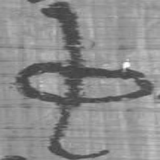

In [2]:
from PIL import Image
from IPython.display import display

cliplet_dir = Path("data/palitchar/cliplets")
image_paths = sorted(
    path for path in cliplet_dir.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

selected_path = random.choice(image_paths)
print(selected_path)
display(Image.open(selected_path).convert("L").resize((160, 160)))

## Predict the Letter

The image is converted to grayscale, resized to `64x64`, normalized, and passed through the released `CNN2D` checkpoint.

In [3]:
import torch

from source import LETTER_LABELS, image_path_to_tensor, load_letterform_model

model = load_letterform_model("best_cnn_letter_model.pth", device="cpu")
image_tensor = image_path_to_tensor(selected_path, device="cpu")

with torch.no_grad():
    logits = model(image_tensor)
    probabilities = torch.softmax(logits, dim=1)[0]
    predicted_index = int(probabilities.argmax())

print("Predicted class:", LETTER_LABELS[predicted_index])
print("Confidence:", round(float(probabilities[predicted_index]), 3))

Predicted class: Phi
Confidence: 0.992
